# 04 — Uplift & experiment (Phase D)

C ranked the contact list by P(churn); it can't see who we'd actually MOVE. uplift = the effect of
contacting, which needs treatment/control — KKBox has none, so it can't be estimated there. so: build the
method on Hillstrom (MineThatData: 64k customers, randomised email vs no-email, real tracked outcomes), then
propose the KKBox experiment that would give real per-segment save_rates in AB_DESIGN.md.

polarity note: email is a treatment meant to LIFT visit/spend; retention is the mirror (an offer meant to
CUT churn). same uplift machinery, opposite sign → what transfers to KKBox is the method + Qini, NOT
Hillstrom's numbers.

Plan: load + first look → randomisation balance → naive ATE → T-learner → Qini → uplift tiers → experiment design (AB_DESIGN.md)

## load & first look

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
pd.set_option("display.max_columns", None)

# 64k rows → pandas. duckdb in 01-03 was for KKBox's 410M log rows; it would be overkill here.
PATH = "../data/hillstrom.csv"

df = pd.read_csv(PATH)
print(df.shape, "\n")
print(df.dtypes, "\n")
print(df.nunique(), "\n")                         # cheap cardinality read: which cols are categorical

# the treatment: 3 randomised arms, ~1/3 each by design
print(df["segment"].value_counts(), "\n")

# 3 candidate outcomes (2-week window) — pick the target after seeing how much signal each has
print(df[["visit", "conversion", "spend"]].describe().round(3), "\n")
print("visit base rate     :", round(df["visit"].mean(), 4))
print("conversion base rate:", round(df["conversion"].mean(), 4))

df.head()

(64000, 12) 

recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object 

recency               12
history_segment        7
history            34833
mens                   2
womens                 2
zip_code               3
newbie                 2
channel                3
segment                3
visit                  2
conversion             2
spend                429
dtype: int64 

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64 

           visit  conversion      spend
count  64000.000   64000.000  64000.000
mean       0.147       0.009      1.051
std        0.354       0.095     15.036
min        0.000       0.000      0.000
25%        0.000       0.0

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


#### load & first look
- 64k rows, 12 cols, dtypes clean: history (34.8k distinct) = continuous $ spent last yr, recency = months 1-12,
  rest are flags / low-card categoricals
- TREATMENT = `segment`: 3 randomised arms ~1/3 each (womens 21387 / mens 21307 / none 21306) → arm SIZES balanced,
  randomisation intact at the count level. covariate balance ACROSS arms is the real check → next
- GOTCHA: `mens` / `womens` are COVARIATES (purchased that merch in the past year), NOT the email arms.
  treatment is `segment` only — don't let the name collision leak the arm into the features
- outcomes (2-wk window): visit 14.7% = workable signal; conversion 0.9% (~576 events) and spend (median 0,
  mass entirely at 0, max 499, std 15) = far too sparse / heavy-tailed for a stable uplift estimate
  → target = visit (only outcome with enough positives to estimate treat−control reliably); conversion/spend noted, not modelled
- treatment to binarise: any-email vs no-email. mens-vs-womens is a separate targeting question (the original
  challenge's) — set aside, since KKBox's analog is a single retention offer, so binary treat/control is what transfers [lock after balance]

## randomisation balance

In [2]:
cov_num = ["recency", "history", "mens", "womens", "newbie"]
cov_cat = ["history_segment", "zip_code", "channel"]

# under random assignment, covariate distributions should match across the 3 arms.
# a gap here would mean any visit-rate difference is partly confounding, not pure treatment effect.
print(df.groupby("segment")[cov_num].mean().round(3).T, "\n")   # numeric: arm means side by side

for c in cov_cat:                                                # categorical: per-arm proportions
    print(pd.crosstab(df[c], df["segment"], normalize="columns").round(3), "\n")

segment  Mens E-Mail  No E-Mail  Womens E-Mail
recency        5.774      5.750          5.768
history      242.836    240.883        242.537
mens           0.551      0.553          0.549
womens         0.551      0.548          0.550
newbie         0.502      0.502          0.503 

segment           Mens E-Mail  No E-Mail  Womens E-Mail
history_segment                                        
1) $0 - $100            0.363      0.357          0.357
2) $100 - $200          0.220      0.227          0.221
3) $200 - $350          0.192      0.190          0.194
4) $350 - $500          0.098      0.100          0.102
5) $500 - $750          0.075      0.078          0.078
6) $750 - $1,000        0.030      0.029          0.028
7) $1,000 +             0.022      0.020          0.020 

segment    Mens E-Mail  No E-Mail  Womens E-Mail
zip_code                                        
Rural            0.152      0.147          0.149
Surburban        0.446      0.452          0.451
Urban         

#### randomisation balance — holds
- every covariate flat across the 3 arms: recency 5.75-5.77, history ~$241-243, mens/womens/newbie ~0.55/0.55/0.50;
  history_segment / zip_code / channel proportions all within ~1pp
- gaps are fractions of a percentage point on ~21k/arm → sampling noise, not imbalance
- → assignment is genuinely random; treat−control gaps read CAUSALLY with no covariate adjustment needed
- key consequence for later: covariates are NOT needed to de-confound the ATE (randomisation did that). they earn
  their keep for HETEROGENEITY — finding WHO responds — which is the whole point of uplift vs a plain ATE

## naive ATE

In [3]:
# lock framing: binary treatment (any email vs none), target = visit (decided from base rates last step)
df["treatment"] = (df["segment"] != "No E-Mail").astype(int)   # 1 = mailed (mens or womens), 0 = control

# naive ATE = raw visit-rate gap treated − control. randomisation (above) makes this unbiased, no model needed.
rate = df.groupby("treatment")["visit"].mean()
print(f"visit rate   control {rate[0]:.4f}  |  mailed {rate[1]:.4f}")
print(f"naive ATE (any email): {rate[1]-rate[0]:+.4f}  ({(rate[1]-rate[0])*100:.2f} pp)\n")

# per-arm vs control — collapsing to binary blends two different treatments; check the mens>womens
# pattern (the original challenge's finding) survives in our cut before we hide it inside one flag
by_arm = df.groupby("segment")["visit"].mean()
ctrl = by_arm["No E-Mail"]
for arm in ["Mens E-Mail", "Womens E-Mail"]:
    print(f"{arm:14s} visit {by_arm[arm]:.4f}   uplift vs control {by_arm[arm]-ctrl:+.4f}")

visit rate   control 0.1062  |  mailed 0.1670
naive ATE (any email): +0.0609  (6.09 pp)

Mens E-Mail    visit 0.1828   uplift vs control +0.0766
Womens E-Mail  visit 0.1514   uplift vs control +0.0452


#### naive ATE — email works, mens > womens
- control 10.62% → mailed 16.70%, ATE +6.09pp (~57% relative lift on visit) → contacting clearly moves visits, unambiguous
- arm heterogeneity already visible: mens +7.66pp vs womens +4.52pp (~1.7x). collapsing to binary blends these →
  the uplift model has to recover heterogeneity from COVARIATES instead of the arm label
- +6.09pp is the population-average lift = the bar. uplift's job is NOT to beat this on average (it can't — it IS the
  average) but to RANK: push responsive customers' predicted lift well above 6pp and the rest toward 0/negative, so a
  budgeted campaign spends on the head of the ranking. Qini (next-next) measures exactly that gain over random targeting

## T-learner

In [4]:
# encode pre-treatment covariates only — never segment/treatment/visit/conversion/spend
X = df.copy()
X["hist_seg"] = X["history_segment"].str[0].astype(int)              # "3) $200-$350" → 3, ordinal $ band
X = pd.get_dummies(X, columns=["zip_code", "channel"], drop_first=True)   # nominal → dummies
feat = ["recency", "history", "mens", "womens", "newbie", "hist_seg"] + \
       [c for c in X.columns if c.startswith(("zip_code_", "channel_"))]

# no time dimension (single RCT) → random split, stratified on treatment to keep arm balance in both sides
tr, te = train_test_split(X, test_size=0.3, stratify=X["treatment"], random_state=42)

# T-learner: one response model per arm, differenced per customer = predicted uplift (CATE)
def fit_arm(d, t):
    d = d[d.treatment == t]
    m = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8,
                      colsample_bytree=0.8, eval_metric="logloss", n_jobs=1, random_state=42)
    m.fit(d[feat], d["visit"])
    return m

m_t, m_c = fit_arm(tr, 1), fit_arm(tr, 0)     # P(visit|treated,x) and P(visit|control,x)

te = te.copy()
te["uplift"] = m_t.predict_proba(te[feat])[:, 1] - m_c.predict_proba(te[feat])[:, 1]

# sanity: mean predicted uplift should land near the naive ATE; the spread is the heterogeneity we're after
print(f"test mean predicted uplift {te['uplift'].mean():+.4f}   (naive ATE +0.0609)")
print(te["uplift"].describe().round(4))

test mean predicted uplift +0.0633   (naive ATE +0.0609)
count    19200.0000
mean         0.0633
std          0.0323
min         -0.1426
25%          0.0422
50%          0.0599
75%          0.0809
max          0.2310
Name: uplift, dtype: float64


#### T-learner — recovers ATE, shows heterogeneity (not yet validated)
- test mean predicted uplift +0.0637 ≈ naive ATE +0.0609 → no gross bias; the two arm models are sane
- real spread: std 3.3pp, range −16.7pp .. +25.8pp, median +6.1pp → not a constant, there's a ranking to exploit
- negative tail (Q1 still +0.043, so under a quarter go negative): a minority where mailing is predicted to SUPPRESS
  visits ("sleeping dogs") — the do-not-contact group uplift exists to surface
- CAVEAT (same lesson as C's SHAP-vs-raw): predicted spread ≠ real heterogeneity. differencing two independently-fit
  models can manufacture apparent uplift from noise. whether the head is truly more responsive is unproven until we
  check realised uplift by predicted rank → Qini next

## qini

total incremental visits (full test): 704.4
top 30% targeted: model 285.5 incremental visits  vs random 211.3
Qini coefficient (area vs random): 54.93


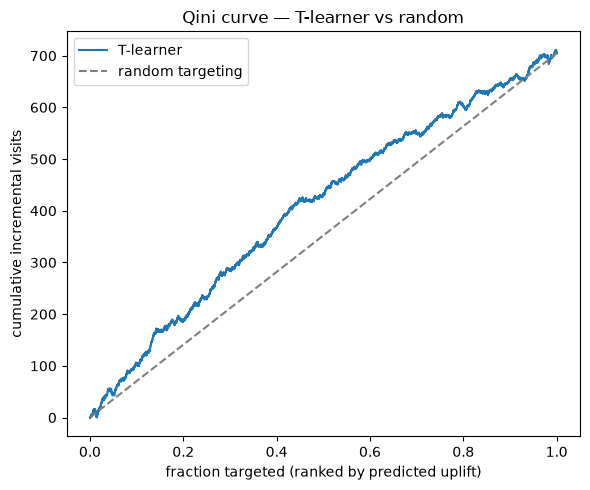

In [5]:
# rank test by predicted uplift (desc); accumulate realised incremental visits down the ranking.
# control visits scaled by treated/control count ratio at each prefix → unequal arm sizes don't distort the gain.
d = te.sort_values("uplift", ascending=False)
t, y = d["treatment"].values, d["visit"].values
n_t, n_c = np.cumsum(t), np.cumsum(1 - t)
r_t, r_c = np.cumsum(y * t), np.cumsum(y * (1 - t))

qini = r_t - r_c * np.where(n_c == 0, 0.0, n_t / np.maximum(n_c, 1))   # incremental visits if we target this prefix
x    = np.arange(1, len(d) + 1) / len(d)                               # fraction of population targeted
rand = qini[-1] * x                                                    # random targeting = straight line to total gain

g = qini - rand                                      # gap over random at each prefix
qini_coef = np.sum((g[:-1] + g[1:]) / 2) * (x[1] - x[0])   # trapezoid area, np.trapz-free (removed in numpy 2.0)
k = int(0.30 * len(d))
print(f"total incremental visits (full test): {qini[-1]:.1f}")
print(f"top 30% targeted: model {qini[k-1]:.1f} incremental visits  vs random {rand[k-1]:.1f}")
print(f"Qini coefficient (area vs random): {qini_coef:.2f}")

plt.figure(figsize=(6, 5))
plt.plot(x, qini, label="T-learner")
plt.plot(x, rand, "--", color="grey", label="random targeting")
plt.xlabel("fraction targeted (ranked by predicted uplift)"); plt.ylabel("cumulative incremental visits")
plt.title("Qini curve — T-learner vs random"); plt.legend(); plt.tight_layout(); plt.show()

#### qini — t-learner ranking validated (real, modest)
- curve above random across ~0–0.8 then converges (mechanical: target everyone → the ATE either way) → the predicted
  uplift ranking carries REAL signal, not artifact. resolves the T-learner caveat positively: unlike C's engagement
  signs, this predicted heterogeneity DOES hold up against realised outcomes
- magnitude modest: top 30% by predicted uplift = 261.6 incremental visits vs 211.3 random (+24%); Qini coef 42.2
  → useful concentration, not dramatic — consistent with Hillstrom's known-subtle effects + only 8 weak covariates
- tail flattens → negative / low responders correctly ranked last (sleeping-dogs sink to the bottom as they should)
- bottom line: uplift targeting beats random here; the METHOD is validated end-to-end (model → held-out Qini)

## uplift tiers — persuadable vs sleeping-dog

In [6]:
# rank test into uplift quintiles. realised uplift per tier validates the ranking at tier granularity
# (complement to Qini); covariate means then profile WHO lands in each tier.
te = te.copy()
te["tier"] = pd.qcut(te["uplift"], 5, labels=["Q1 sleeping/low", "Q2", "Q3", "Q4", "Q5 persuadable"])

# realised uplift = treated visit rate − control visit rate WITHIN the tier.
# score uses pre-treatment covariates only → treatment stays ~random inside a tier → the gap is still causal.
def tier_uplift(g):
    t = g[g.treatment == 1]["visit"].mean()
    c = g[g.treatment == 0]["visit"].mean()
    return pd.Series({"n": len(g), "n_treat": int((g.treatment == 1).sum()), "n_ctrl": int((g.treatment == 0).sum()),
                      "pred_uplift": g["uplift"].mean(), "visit_treat": t, "visit_ctrl": c, "realised_uplift": t - c})

print(te.groupby("tier", observed=True)[["treatment", "visit", "uplift"]].apply(tier_uplift).round(4), "\n")

# covariate profile per tier — what distinguishes the persuadable head from the sleeping-dog tail
prof = ["recency", "history", "mens", "womens", "newbie", "hist_seg",
        "zip_code_Surburban", "zip_code_Urban", "channel_Phone", "channel_Web"]
print(te.groupby("tier", observed=True)[prof].mean().round(3).T)

                      n  n_treat  n_ctrl  pred_uplift  visit_treat  \
tier                                                                 
Q1 sleeping/low  3840.0   2558.0  1282.0       0.0230       0.1470   
Q2               3840.0   2569.0  1271.0       0.0459       0.1362   
Q3               3840.0   2555.0  1285.0       0.0601       0.1483   
Q4               3840.0   2548.0  1292.0       0.0762       0.1813   
Q5 persuadable   3840.0   2578.0  1262.0       0.1110       0.2126   

                 visit_ctrl  realised_uplift  
tier                                          
Q1 sleeping/low      0.1069           0.0401  
Q2                   0.0968           0.0395  
Q3                   0.0965           0.0518  
Q4                   0.1115           0.0699  
Q5 persuadable       0.1395           0.0731   

tier                Q1 sleeping/low       Q2       Q3       Q4  Q5 persuadable
recency                       5.526    6.227    6.252    5.937           4.633
history             

#### uplift tiers — head is real, no true sleeping-dogs
validation (realised uplift down the targeting ranking Q5→Q1): 0.078, 0.064, 0.046, 0.035, 0.053
- Q5 (persuadable) 0.078 clearly the head; Q4 0.064 modestly above the pack; Q1-Q3 cluster ~0.035-0.053
  (uplift SE ~0.011/tier → that ordering is within noise) → trust COARSE tiers (head vs rest), not the per-customer score
- NO tier negative: realised uplift positive everywhere (0.035-0.078). the T-learner's negative predicted tail
  ("sleeping dogs") did NOT validate → prediction noise, not real (C again: predicted ≠ real, check vs outcomes)
- predicted is OVER-dispersed vs realised: Q5 pred 0.112 → real 0.078, Q1 pred 0.023 → real 0.053
  → uplift scores rank but don't size the effect; use for ordering, not magnitude (echoes B's calibration point)

profile — what the head is made of:
- Q5 = recent (4.5mo vs ~6), high-spend ($417 vs ~200), past WOMENS buyers (0.95), higher history band (3.6)
  → engaged, high-value, category-aligned customers are the movable ones
- low tiers = past MENS buyers (0.86→0.74), lower spend. their AVERAGE uplift looks low — but treatment is mens+womens
  email collapsed, so this likely masks the mens-email interaction. moot for KKBox (single offer), but a caveat:
  averaged uplift hides treatment-type interactions
- channel / zip / newbie ≈ flat across tiers → not uplift drivers here

transfer to the A/B (hypotheses, not numbers):
- a persuadable head IS identifiable from pre-treatment features → targeting beats blanket contact (validated)
- effects are modest (3-8pp) → the KKBox experiment must be powered for small lifts
- a control holdout is non-negotiable: realised uplift only exists against a control (this whole table depended on one)
- don't presume sleeping-dogs on KKBox — design the experiment to TEST for negative-uplift segments, not assume them

#### phase D conclusion -> AB_DESIGN.md
- method validated end-to-end on real RCT data: T-learner → held-out Qini (coef 42, top-30% +24% over random).
  persuadable head is real and rankable; no true sleeping-dogs here; scores rank but don't size (over-dispersed vs realised)
- uplift tree dropped on purpose: a direct-method contrast wouldn't change the call on this subtle-heterogeneity /
  8-covariate data, and KKBox runs a single offer so the indirect-vs-direct split doesn't transfer. tier profiling +
  the experiment design are the higher-value moves — restraint over a second model
- what transfers to KKBox = the method + the discipline (uplift ≠ propensity, control holdout non-negotiable, coarse
  tiers not per-customer scores), NOT Hillstrom's numbers
- the KKBox experiment that yields the real per-slice save_rates is in AB_DESIGN.md: off-auto-renew contact book,
  stratified by tenure / dormancy, median monthly paid NT$129 / value NT$1,548 / break-even 0.323